# Copyright (C) 2026 Bruno Proença de Souza
# Licenciado sob GNU AGPL v3 - veja o arquivo LICENSE


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                   ETAPA 1: CARREGAMENTO E VALIDAÇÃO DE DADOS                   
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[2026-06-12 13:33:55] ℹ️ INFO     | Diretório atual: c:\Users\bruno\Desktop\Pipeline_TCC\src\analise_exploratoria\IDW
[2026-06-12 13:33:55] ℹ️ INFO     | Procurando arquivo: c:\Users\bruno\Desktop\Pipeline_TCC\data\processed\dataset_final.parquet
[2026-06-12 13:33:55] ℹ️ INFO     | Variável selecionada: RH2M_dec35_ano1
[2026-06-12 13:33:55] ℹ️ INFO     | Cores invertidas: não
[2026-06-12 13:33:55] ✅ SUCCESS  | Dataset carregado com sucesso | 2,793 registros | 2,982 colunas
[2026-06-12 13:33:55] ✅ SUCCESS  | Todas as colunas requeridas validadas
[2026-06-12 13:33:55] ✅ SUCCESS  | Conversões de tipo concluídas

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
               ETAPA 2: CARREGAMENTO DE REFERÊNCIAS GEOES

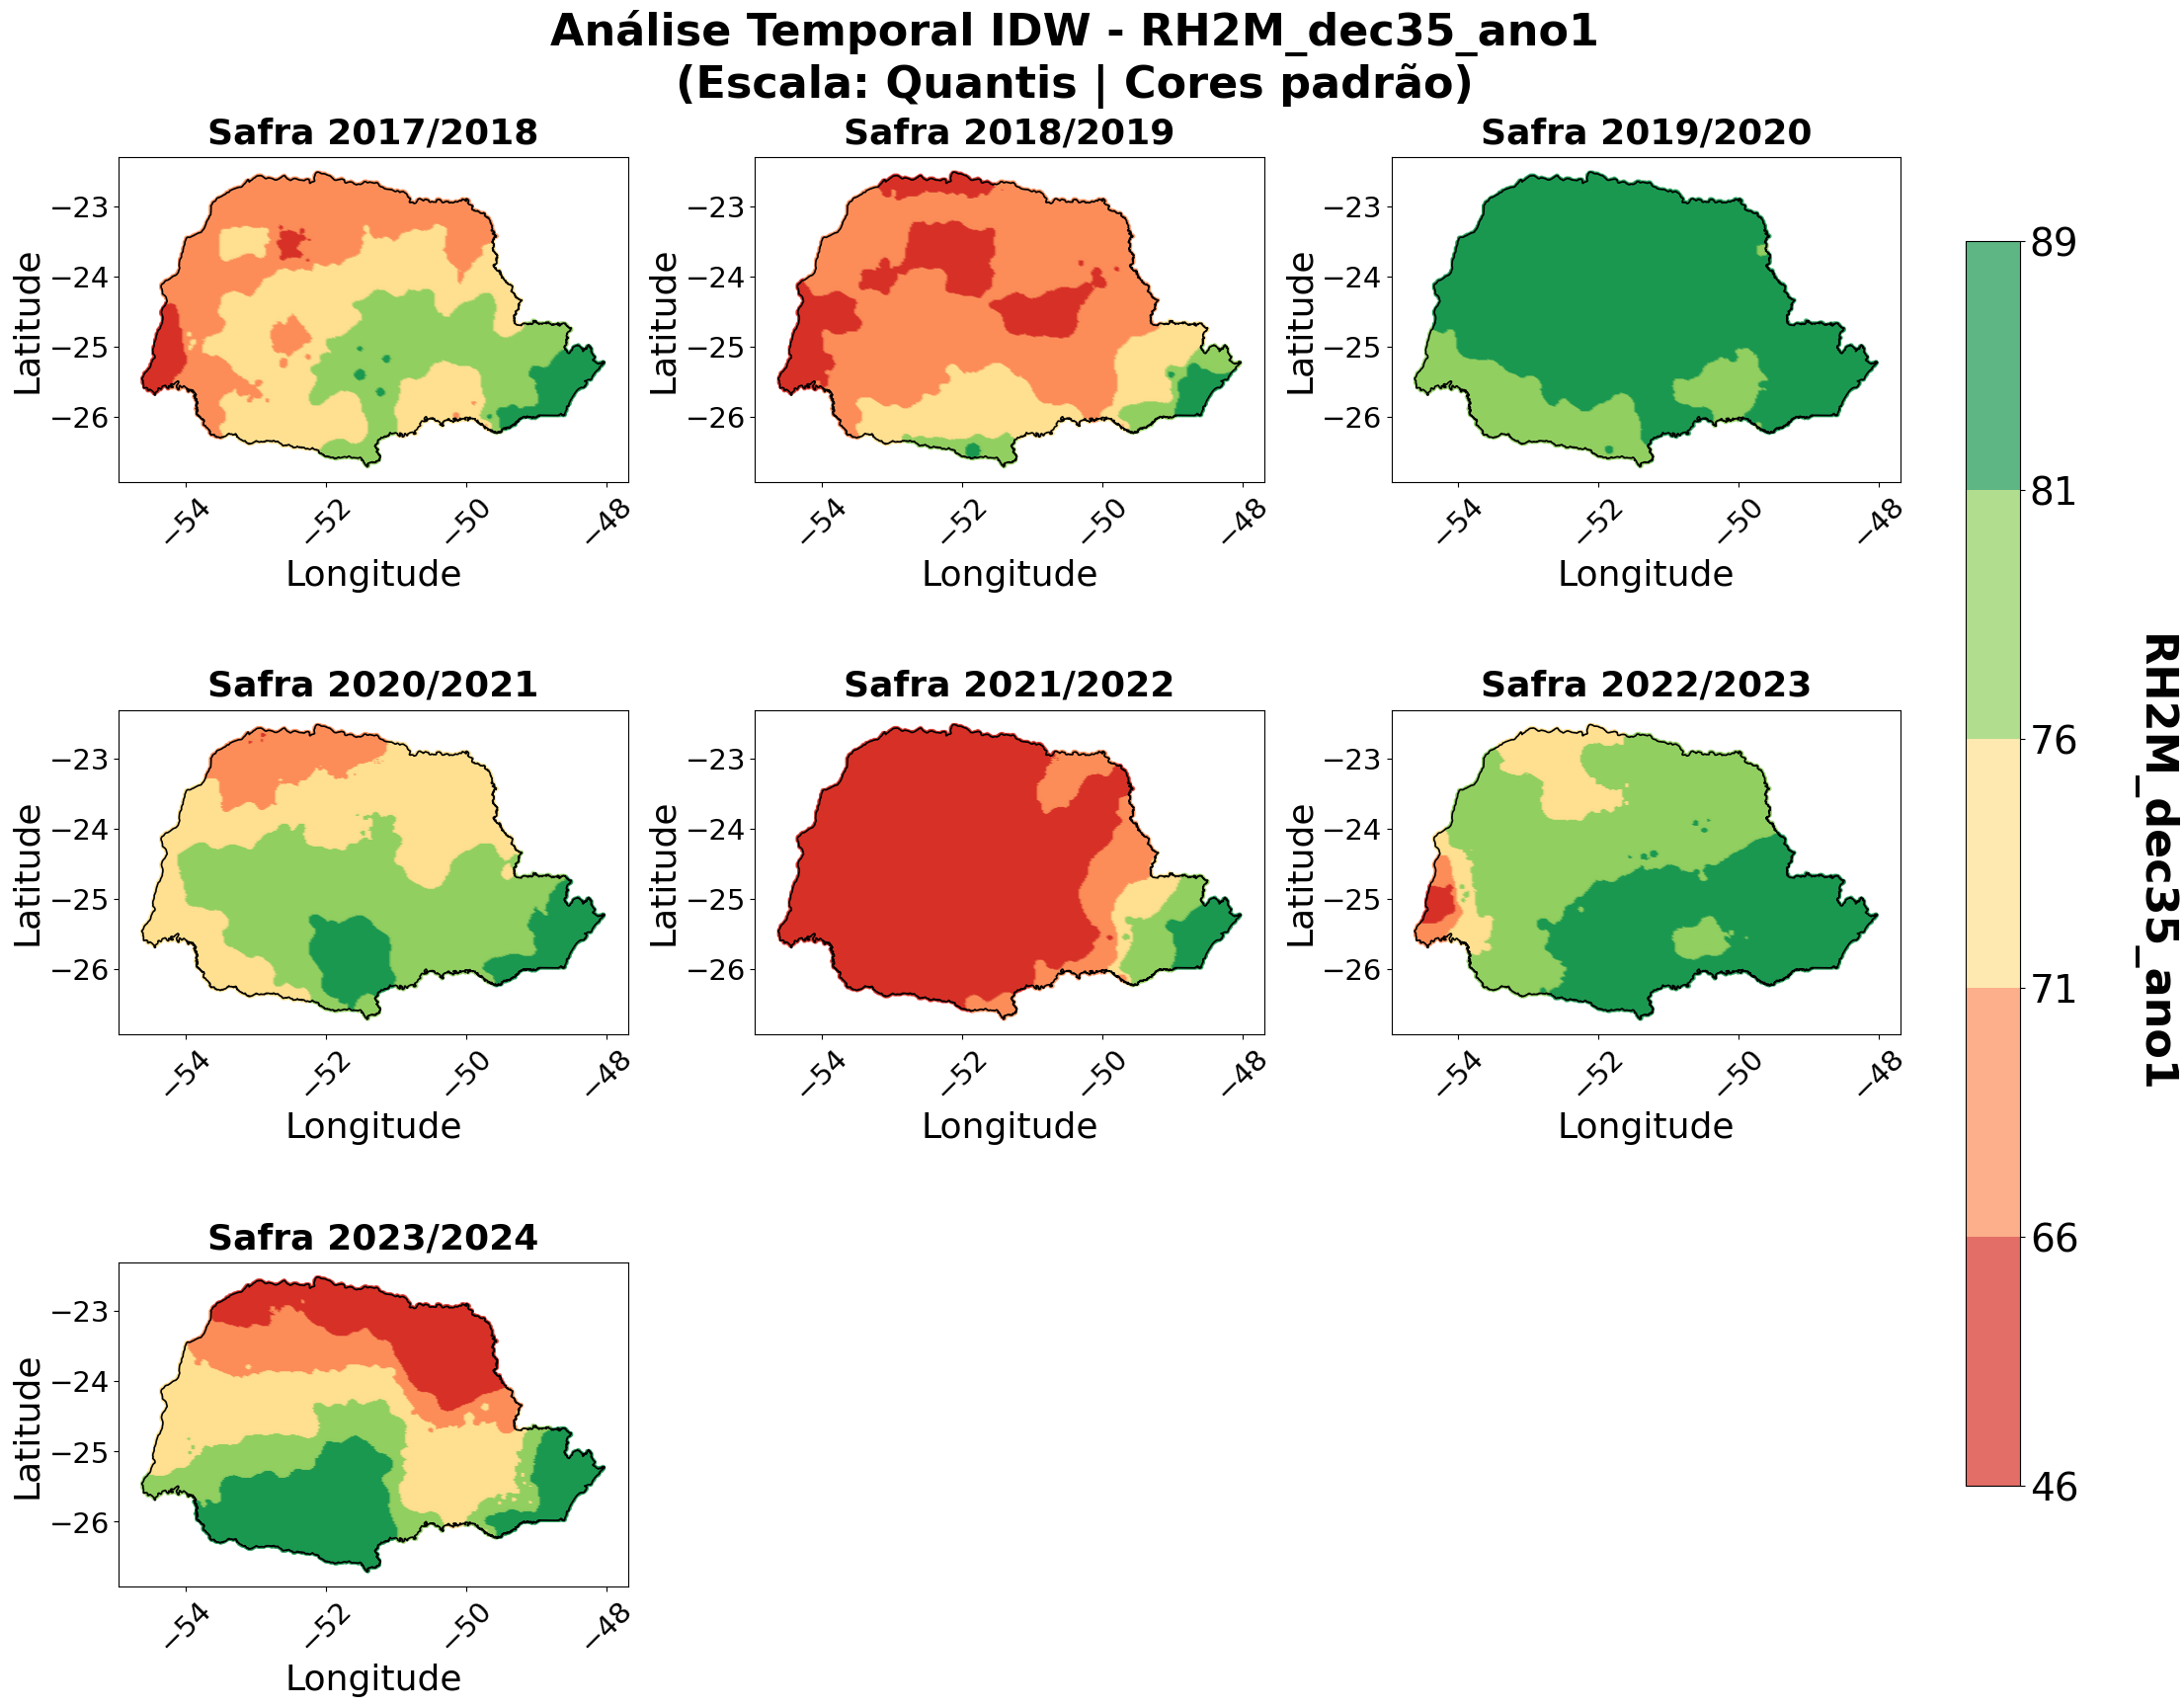

[2026-06-12 13:34:31] ✅ SUCCESS  | Visualização renderizada com sucesso
[2026-06-12 13:34:31] ✅ SUCCESS  | Figura salva em: c:\Users\bruno\Desktop\Pipeline_TCC\data\eda_outputs_teste\idw_temporal_parana_RH2M_dec35_ano1_cores_normais.png

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                          PROCESSO CONCLUÍDO COM ÊXITO                          
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[2026-06-12 13:34:31] ✅ SUCCESS  | Variável processada: RH2M_dec35_ano1
[2026-06-12 13:34:31] ✅ SUCCESS  | Cores invertidas: não


In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.spatial import cKDTree
from shapely.geometry import Point
import warnings
from datetime import datetime
from pathlib import Path

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CONFIGURAÇÃO VIA INPUT
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
VARIAVEL_PADRAO = 'rendimento_kg_ha'
TIPO_ESCALA = 'quantis'  # 'quantis', 'log' ou 'linear'
RESOLUCAO_GRADE = 300
K_VIZINHOS_IDW = 8
POTENCIA_IDW = 2

try:
    variavel_input = input(f'Digite a variável para o IDW [{VARIAVEL_PADRAO}]: ').strip()
except EOFError:
    variavel_input = ''

try:
    cor_inversa_input = input('Inverter escala de cores? (s/N): ').strip().lower()
except EOFError:
    cor_inversa_input = ''

VARIAVEL_IDW = variavel_input or VARIAVEL_PADRAO
COR_INVERSA = cor_inversa_input in {'s', 'sim', 'y', 'yes', '1'}


# Detecção inteligente do caminho do projeto
def encontrar_arquivo_parquet():
    """Localiza dataset_final.parquet procurando na hierarquia de diretórios."""
    nome_arquivo = 'dataset_final.parquet'
    caminho_esperado = Path.cwd() / 'data' / 'processed' / nome_arquivo

    if caminho_esperado.exists():
        return caminho_esperado

    for parent in Path.cwd().parents:
        arquivo = parent / 'data' / 'processed' / nome_arquivo
        if arquivo.exists():
            return arquivo

    return caminho_esperado


ARQUIVO_PARQUET = encontrar_arquivo_parquet()
PROJECT_ROOT = ARQUIVO_PARQUET.parents[2]
PASTA_SAIDA = PROJECT_ROOT / 'data' / 'eda_outputs_teste'
ARQUIVO_SAIDA = PASTA_SAIDA / f'idw_temporal_parana_{VARIAVEL_IDW}_{"cores_invertidas" if COR_INVERSA else "cores_normais"}.png'

COL_ANO = 'ano'
COL_IBGE = 'cod_ibge'
COL_MUNICIPIO = 'municipio'
COL_LAT = 'latitude'
COL_LON = 'longitude'


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FUNÇÕES AUXILIARES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def log_info(msg: str, level: str = 'INFO'):
    """Log profissional com timestamp."""
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    levels = {'INFO': 'ℹ️', 'SUCCESS': '✅', 'WARNING': '⚠️', 'ERROR': '❌'}
    symbol = levels.get(level, '•')
    print(f'[{timestamp}] {symbol} {level:8s} | {msg}')


def log_section(title: str):
    """Cabeçalho de seção."""
    print(f"\n{'━'*80}\n{title:^80}\n{'━'*80}\n")


def listar_variaveis_numericas(df, limite=80):
    ignorar = {COL_IBGE, COL_ANO, COL_LAT, COL_LON, 'cod_meso'}
    variaveis = [col for col in df.select_dtypes(include='number').columns if col not in ignorar]
    return variaveis if limite is None else variaveis[:limite]


def carregar_poligono_parana(dados_base):
    try:
        from geobr import read_state
        estado = read_state(code_state='PR')
        if estado.crs is None:
            estado = estado.set_crs('EPSG:4674')
        return estado.to_crs('EPSG:4674'), 'geobr.read_state(PR)'
    except Exception as exc:
        log_info(f'Falha ao carregar limite oficial via geobr: {exc}', 'WARNING')
        log_info('Usando contorno aproximado a partir dos pontos municipais', 'WARNING')
        pontos = dados_base.drop_duplicates(subset=COL_IBGE).dropna(subset=[COL_LAT, COL_LON])
        gdf_pontos = gpd.GeoDataFrame(
            pontos,
            geometry=gpd.points_from_xy(pontos[COL_LON], pontos[COL_LAT]),
            crs='EPSG:4674'
        )
        contorno = gdf_pontos.union_all().convex_hull.buffer(0.25)
        estado = gpd.GeoDataFrame({'name_state': ['Parana']}, geometry=[contorno], crs='EPSG:4674')
        return estado, 'contorno aproximado dos municipios'


def idw_interpolation(xy, values, grid_points, k=8, p=2):
    """Inverse Distance Weighting interpolation."""
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        tree = cKDTree(xy)
        k = min(k, len(xy))
        distances, indices = tree.query(grid_points, k=k)

        if k == 1:
            distances = distances[:, None]
            indices = indices[:, None]

        distances = np.where(distances == 0, 1e-10, distances)
        weights = 1.0 / (distances ** p)
        weights /= weights.sum(axis=1)[:, None]
        return (weights * values[indices]).sum(axis=1)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 0. CARREGAMENTO DE DADOS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
log_section('ETAPA 1: CARREGAMENTO E VALIDAÇÃO DE DADOS')

log_info(f'Diretório atual: {Path.cwd()}')
log_info(f'Procurando arquivo: {ARQUIVO_PARQUET}')
log_info(f'Variável selecionada: {VARIAVEL_IDW}')
log_info(f'Cores invertidas: {"sim" if COR_INVERSA else "não"}')

if not ARQUIVO_PARQUET.exists():
    log_info(f'ARQUIVO NÃO ENCONTRADO: {ARQUIVO_PARQUET}', 'ERROR')
    raise FileNotFoundError(f'Dataset não encontrado em: {ARQUIVO_PARQUET}')

try:
    df = pd.read_parquet(ARQUIVO_PARQUET)
    log_info(f'Dataset carregado com sucesso | {len(df):,} registros | {len(df.columns):,} colunas', 'SUCCESS')
except Exception as e:
    log_info(f'Falha ao carregar dataset: {e}', 'ERROR')
    raise

colunas_requeridas = [COL_ANO, COL_IBGE, COL_MUNICIPIO, COL_LAT, COL_LON, VARIAVEL_IDW]
colunas_faltantes = [col for col in colunas_requeridas if col not in df.columns]

if colunas_faltantes:
    log_info(f'Colunas faltantes: {colunas_faltantes}', 'ERROR')
    log_info('Primeiras variáveis numéricas disponíveis:', 'INFO')
    for coluna in listar_variaveis_numericas(df, limite=80):
        print(f'  - {coluna}')
    raise ValueError(f'Colunas requeridas não encontradas: {colunas_faltantes}')

df[COL_LAT] = pd.to_numeric(df[COL_LAT], errors='coerce')
df[COL_LON] = pd.to_numeric(df[COL_LON], errors='coerce')
df[COL_ANO] = pd.to_numeric(df[COL_ANO], errors='coerce').astype('Int64')
df[VARIAVEL_IDW] = pd.to_numeric(df[VARIAVEL_IDW], errors='coerce')

log_info('Todas as colunas requeridas validadas', 'SUCCESS')
log_info('Conversões de tipo concluídas', 'SUCCESS')


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 1. CARREGAMENTO DO SHAPEFILE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
log_section('ETAPA 2: CARREGAMENTO DE REFERÊNCIAS GEOESPACIAIS')

estado, origem_poligono = carregar_poligono_parana(df)
log_info(f'Polígono carregado | Origem: {origem_poligono} | CRS: {estado.crs}', 'SUCCESS')


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 2. CRIAÇÃO DE GRADE DE INTERPOLAÇÃO
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
log_section('ETAPA 3: CONSTRUÇÃO DA GRADE DE INTERPOLAÇÃO')

log_info(f'Gerando grade regular de {RESOLUCAO_GRADE}×{RESOLUCAO_GRADE} pontos')
minx, miny, maxx, maxy = estado.total_bounds
grid_x, grid_y = np.meshgrid(
    np.linspace(minx, maxx, RESOLUCAO_GRADE),
    np.linspace(miny, maxy, RESOLUCAO_GRADE)
)
grid_points = np.vstack([grid_x.ravel(), grid_y.ravel()]).T

poligono_pr = estado.union_all()
grid_points_geom = gpd.GeoSeries([Point(xy) for xy in grid_points], crs=estado.crs)
mask = grid_points_geom.within(poligono_pr)
grid_points = grid_points[mask.values]

log_info(f'Grade criada com {len(grid_points):,} pontos válidos (dentro do estado)', 'SUCCESS')


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 3. PROCESSAMENTO DE DADOS POR ANO (CACHE)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
log_section('ETAPA 4: CONSTRUÇÃO DE CACHE GEOESPACIAL POR ANO')

anos_unicos = sorted(df[COL_ANO].dropna().astype(int).unique().tolist())
log_info(f'Processando {len(anos_unicos)} ano(s): {min(anos_unicos)}-{max(anos_unicos)}')

gdf_cache = {}

for ano in anos_unicos:
    df_ano = (
        df[df[COL_ANO] == ano]
        .copy()
        .drop_duplicates(subset=COL_IBGE, keep='first')
        .dropna(subset=[COL_LAT, COL_LON, VARIAVEL_IDW])
    )

    if df_ano.empty:
        log_info(f'Ano {ano}: sem dados disponíveis', 'WARNING')
        continue

    gdf_pontos = gpd.GeoDataFrame(
        df_ano,
        geometry=gpd.points_from_xy(df_ano[COL_LON], df_ano[COL_LAT]),
        crs=estado.crs
    )
    gdf_pontos = gdf_pontos[gdf_pontos.geometry.within(poligono_pr)]

    if not gdf_pontos.empty:
        gdf_cache[ano] = gdf_pontos
        log_info(f'Ano {ano}: {len(gdf_pontos):,} municípios carregados', 'SUCCESS')

log_info(f'Cache construído para {len(gdf_cache)} ano(s)', 'SUCCESS')


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 4. PROCESSAMENTO PRINCIPAL - VARIÁVEL VIA INPUT
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
log_section('ETAPA 5: ANÁLISE TEMPORAL IDW - PROCESSAMENTO DA VARIÁVEL')

todos_valores = []
dados_interpolados_por_ano = {}
anos_com_dados = []

for ano in anos_unicos:
    if ano not in gdf_cache:
        continue

    gdf_pontos = gdf_cache[ano]
    dados_validos = gdf_pontos[[VARIAVEL_IDW, 'geometry']].copy()
    dados_validos[VARIAVEL_IDW] = pd.to_numeric(dados_validos[VARIAVEL_IDW], errors='coerce')
    dados_validos = dados_validos.dropna(subset=[VARIAVEL_IDW])
    dados_validos = dados_validos[np.isfinite(dados_validos[VARIAVEL_IDW])]

    if len(dados_validos) < 3:
        log_info(f'Ano {ano}: menos de 3 pontos válidos para IDW', 'WARNING')
        continue

    valores = dados_validos[VARIAVEL_IDW].values.astype(float)
    todos_valores.extend(valores)

    xy = np.vstack((dados_validos.geometry.x, dados_validos.geometry.y)).T
    dados_interpolados_por_ano[ano] = idw_interpolation(
        xy, valores, grid_points, k=K_VIZINHOS_IDW, p=POTENCIA_IDW
    )
    anos_com_dados.append(ano)

if not dados_interpolados_por_ano:
    raise ValueError(f'Variável {VARIAVEL_IDW} sem dados suficientes para IDW')

todos_valores_array = np.array(todos_valores, dtype=float)
todos_valores_array = todos_valores_array[np.isfinite(todos_valores_array)]
todos_valores_positivos = todos_valores_array[todos_valores_array > 0]
valores_escala = todos_valores_positivos if len(todos_valores_positivos) else todos_valores_array

if TIPO_ESCALA == 'quantis':
    limites = np.unique(np.percentile(valores_escala, [0, 20, 40, 60, 80, 100]))
elif TIPO_ESCALA == 'log':
    if len(todos_valores_positivos) == 0:
        raise ValueError('Escala logarítmica requer valores positivos')
    limites = np.logspace(
        np.log10(np.nanmin(todos_valores_positivos)),
        np.log10(np.nanmax(todos_valores_positivos)), 6
    )
else:
    limites = np.linspace(np.nanmin(valores_escala), np.nanmax(valores_escala), 6)

if len(limites) < 2:
    raise ValueError(f'Variável {VARIAVEL_IDW} não possui variação suficiente para escala de cores')

cores_base = ['#d73027', '#fc8d59', '#fee090', '#91cf60', '#1a9850']
cores = list(reversed(cores_base)) if COR_INVERSA else cores_base
cmap = ListedColormap(cores)
norm = BoundaryNorm(limites, cmap.N)

# Figura no mesmo padrão do IDW_analise.ipynb
fig, axes = plt.subplots(3, 3, figsize=(22, 18), squeeze=False)
axes_flat = axes.flatten()
sc_ref = None

for i, ano in enumerate(anos_unicos):
    ax = axes_flat[i]
    if ano not in dados_interpolados_por_ano:
        ax.set_visible(False)
        continue

    sc = ax.scatter(
        grid_points[:, 0], grid_points[:, 1],
        c=dados_interpolados_por_ano[ano],
        cmap=cmap, norm=norm, alpha=0.7, s=8
    )
    if sc_ref is None:
        sc_ref = sc

    estado.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.2)
    ax.set_title(f'Safra {ano-1}/{ano}', fontsize=26, fontweight='bold', pad=10)
    ax.set_xlabel('Longitude', fontsize=26)
    ax.set_ylabel('Latitude', fontsize=26)
    ax.tick_params(axis='x', labelsize=21, rotation=45, pad=3)
    ax.tick_params(axis='y', labelsize=21, pad=3)
    ax.set_aspect('equal', adjustable='box')

for j in range(len(anos_unicos), len(axes_flat)):
    axes_flat[j].set_visible(False)

escala_texto = {'quantis': 'Quantis', 'log': 'Logarítmica', 'linear': 'Linear'}
cor_texto = 'Cores invertidas' if COR_INVERSA else 'Cores padrão'
fig.suptitle(
    f'Análise Temporal IDW - {VARIAVEL_IDW}\n(Escala: {escala_texto[TIPO_ESCALA]} | {cor_texto})',
    fontsize=32, fontweight='bold', y=0.98
)
fig.subplots_adjust(top=0.93, bottom=0.06, left=0.06, right=0.88, hspace=0.25, wspace=0.25)

if sc_ref:
    cbar_ax = fig.add_axes([0.91, 0.15, 0.025, 0.7])
    fmt = '%.0e' if TIPO_ESCALA == 'log' else '%.0f'
    cbar = fig.colorbar(sc_ref, cax=cbar_ax, boundaries=limites, ticks=limites, format=fmt)
    cbar.set_label(VARIAVEL_IDW, rotation=270, labelpad=70, fontsize=32, fontweight='bold')
    cbar.ax.tick_params(labelsize=28)

PASTA_SAIDA.mkdir(parents=True, exist_ok=True)
fig.savefig(ARQUIVO_SAIDA, dpi=180, bbox_inches='tight')
plt.show()

log_info('Visualização renderizada com sucesso', 'SUCCESS')
log_info(f'Figura salva em: {ARQUIVO_SAIDA}', 'SUCCESS')

log_section('PROCESSO CONCLUÍDO COM ÊXITO')
log_info(f'Variável processada: {VARIAVEL_IDW}', 'SUCCESS')
log_info(f'Cores invertidas: {"sim" if COR_INVERSA else "não"}', 'SUCCESS')